In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from jiflr import ROOT
from jiflr.data import select_sensors, merge_sensor_datasets
from jiflr.utils import butterworth_filter, calculate_lapse_rate_timestep, lapse_rate_ufunc
from scipy import stats
import os


plt.style.use("default")
plt.ioff()

In [6]:
# Load pendant data
ds_pendants = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds_pendants = select_sensors(ds_pendants, height="0m", shielding="unshielded")

# Drop sensors missing coordinates (e.g. G03A, G03B)
ds_pendants = ds_pendants.isel(sensor_idx=~np.isnan(ds_pendants.latitude.values))

# Load intensive site data and filter to shielded pendants
ds_intensive = xr.open_dataset(
    ROOT / "data/2025/processed/lvl1/lvl1_on_ice_intensive.nc"
)
ds_intensive = select_sensors(ds_intensive, height="0m", shielding="unshielded")

# Merge datasets
ds = merge_sensor_datasets(ds_pendants, ds_intensive)

print(f"Dataset dimensions: {dict(ds.sizes)}")
print(f"Dataset variables: {list(ds.data_vars)}")
print(f"Available site_ids: {sorted(ds.site_id.values.tolist())}")

Dataset dimensions: {'datetime': 25578, 'sensor_idx': 2}
Dataset variables: ['temp_c', 'intensity_lux']
Available site_ids: ['A06', 'A10']


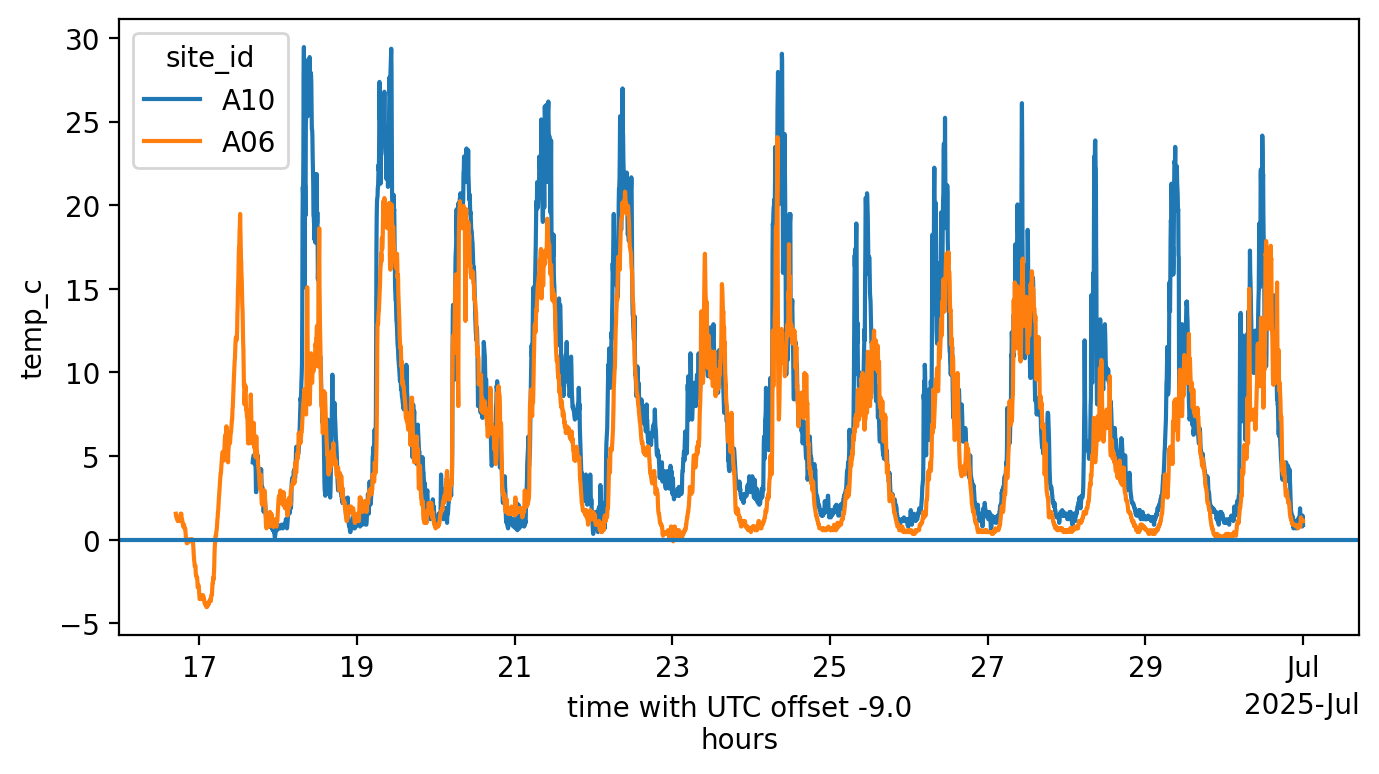

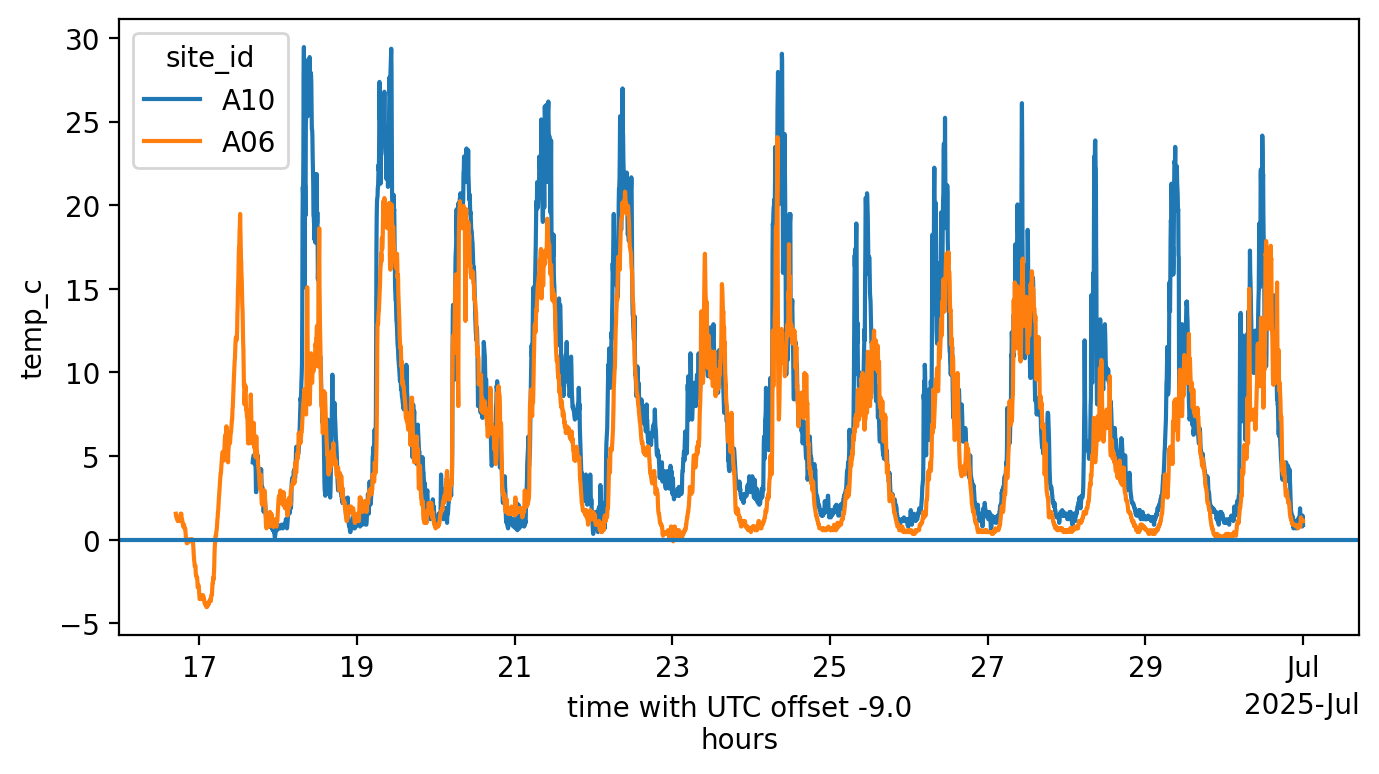

In [9]:
fig, ax = plt.subplots(1,1, figsize=(8,4), dpi=200)
ds.sel(datetime=slice(pd.Timestamp("06/01/25"), pd.Timestamp("07/1/25")))["temp_c"].plot.line(hue="site_id", x="datetime", ax=ax)
ax.axhline(0)

fig